# Odometry Example

GTSAM models estimation problems as **factor graphs**: a bipartite graph of *variables* (things we want to estimate) and *factors* (measurement constraints between them). This notebook builds the smallest interesting factor graph -- a robot driving in a straight line -- and is a good first look at what a factor graph actually is.

- **Variables**: three `Pose2` robot poses `(x, y, \theta)`, at times 1, 2, 3.
- **Factors**: a `PriorFactor` anchoring the first pose at the origin, and two `BetweenFactor`s encoding noisy odometry -- "the robot believes it moved 2 meters forward" -- between consecutive poses.

We build the graph, optimize it with Levenberg-Marquardt, and then look at the marginal covariances to see how uncertainty accumulates as the robot drives.

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/OdometryExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import gtsam
import gtsam.utils.plot as gtsam_plot
import matplotlib.pyplot as plt
import numpy as np

## 1. Noise models

Both factors below use `noiseModel.Diagonal.Sigmas`, which lets us give each dimension of a `Pose2` -- `x`, `y`, `\theta` -- its own standard deviation, unlike the `Isotropic` model (a single sigma for every dimension) used in the GPS factor example. Here we trust `\theta` more than `x`/`y`, since the robot's odometry is better at tracking heading than position.

In [3]:
ODOMETRY_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1]))

## 2. Build the factor graph

The `PriorFactorPose2` pins pose `1` at the origin -- without it, the whole chain of poses could float anywhere, since odometry only measures *relative* motion. Each `BetweenFactorPose2` then says "the robot believes it moved this `Pose2` -- 2 meters forward, no turn -- between these two poses." We reuse the same odometry measurement and noise model for both steps, since the robot drives the same way twice.

In [4]:
graph = gtsam.NonlinearFactorGraph()

# Add a prior on the first pose, setting it to the origin
# A prior factor consists of a mean and a noise model (covariance matrix)
priorMean = gtsam.Pose2(0.0, 0.0, 0.0)  # prior at origin
graph.add(gtsam.PriorFactorPose2(1, priorMean, PRIOR_NOISE))

# Add odometry factors
odometry = gtsam.Pose2(2.0, 0.0, 0.0)
# For simplicity, we will use the same noise model for each odometry factor
# Create odometry (Between) factors between consecutive poses
graph.add(gtsam.BetweenFactorPose2(1, 2, odometry, ODOMETRY_NOISE))
graph.add(gtsam.BetweenFactorPose2(2, 3, odometry, ODOMETRY_NOISE))

print(graph)

NonlinearFactorGraph: size: 3

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];




## 3. Initial estimate

For illustrative purposes, the initial estimate for each pose is deliberately set to noisy, imprecise values -- not the origin, and not exactly 2 meters apart -- so the optimizer has real work to do.

In [5]:
initial = gtsam.Values()
initial.insert(1, gtsam.Pose2(0.5, 0.0, 0.2))
initial.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initial.insert(3, gtsam.Pose2(4.1, 0.1, 0.1))
print(initial)

Values with 3 values:
Value 1: (gtsam::Pose2)
(0.5, 0, 0.2)

Value 2: (gtsam::Pose2)
(2.3, 0.1, -0.2)

Value 3: (gtsam::Pose2)
(4.1, 0.1, 0.1)




## 4. Optimize

As in the GPS factor example, we solve with `LevenbergMarquardtOptimizer`.

In [6]:
params = gtsam.LevenbergMarquardtParams()
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
result = optimizer.optimize()
print(result)

Values with 3 values:
Value 1: (gtsam::Pose2)
(7.46978315e-16, -5.34409096e-16, -1.78381863e-16)

Value 2: (gtsam::Pose2)
(2, -1.09236636e-15, -2.48671179e-16)

Value 3: (gtsam::Pose2)
(4, -1.70076056e-15, -2.50943863e-16)




## 5. Marginal covariances

Beyond the best-estimate poses, GTSAM can also compute the **marginal covariance** of each variable -- how uncertain we are about it, given every factor in the graph. We'd expect pose 1 to be tightly constrained by its prior, and the uncertainty to grow for poses 2 and 3 as odometry noise accumulates along the direction of travel.

In [7]:
marginals = gtsam.Marginals(graph, result)
for i in range(1, 4):
    print("X{} covariance:\n{}\n".format(i, marginals.marginalCovariance(i)))

X1 covariance:
[[9.00000000e-02 2.92775369e-33 3.54987407e-33]
 [2.92775369e-33 9.00000000e-02 2.55795385e-17]
 [3.54987407e-33 2.55795385e-17 1.00000000e-02]]

X2 covariance:
[[1.30000000e-01 1.21229810e-18 6.06149052e-19]
 [1.21229810e-18 1.70000000e-01 2.00000000e-02]
 [6.06149052e-19 2.00000000e-02 2.00000000e-02]]

X3 covariance:
[[1.70000000e-01 8.63317033e-18 2.69082498e-18]
 [8.63317033e-18 3.70000000e-01 6.00000000e-02]
 [2.69082498e-18 6.00000000e-02 3.00000000e-02]]



## 6. Visualize

`gtsam.utils.plot.plot_pose2` draws each pose as an axis triad together with a covariance ellipse, so we can see the growing uncertainty directly instead of just reading numbers.

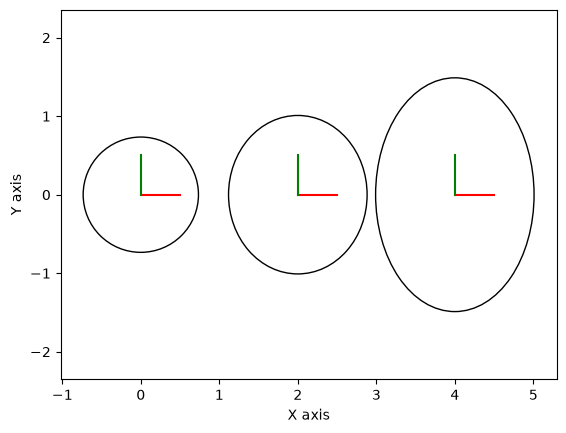

In [8]:
for i in range(1, 4):
    gtsam_plot.plot_pose2(0, result.atPose2(i), 0.5, marginals.marginalCovariance(i))
plt.axis('equal')
plt.show()

Notice how the covariance ellipse for pose 1 is small and round -- it's pinned only by the prior, whose sigmas are equal in x and y. For poses 2 and 3, the ellipses grow overall, but not evenly: they stretch more *sideways* (perpendicular to the direction of travel) than forward. This is the classic dead-reckoning "lever-arm" effect -- heading uncertainty at an earlier pose, carried forward over each 2-meter step, turns into extra lateral position uncertainty at the next pose, on top of the odometry noise itself. It's the same effect behind the "banana-shaped" uncertainty regions common in dead-reckoning navigation, and exactly why SLAM systems add loop-closure or absolute measurements (like the GPS factor in `GPSFactorExample`) to keep it in check.